In [68]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn import preprocessing
import matplotlib.pyplot as plt

#loading the data

In [69]:
df = pd.read_csv('Audiobooks_data.csv',delimiter =',')

#creating input and target

In [70]:
input_data = df.iloc[:,1:-1]
target_data = df.iloc[:,-1]

In [71]:
zero_counter = 0
indices_to_remove = []
one_data_all = np.sum(target_data)

for i in range(target_data.shape[0]):
  if target_data[i] == 0:
    zero_counter += 1
    if zero_counter > one_data_all:
      indices_to_remove.append(i)


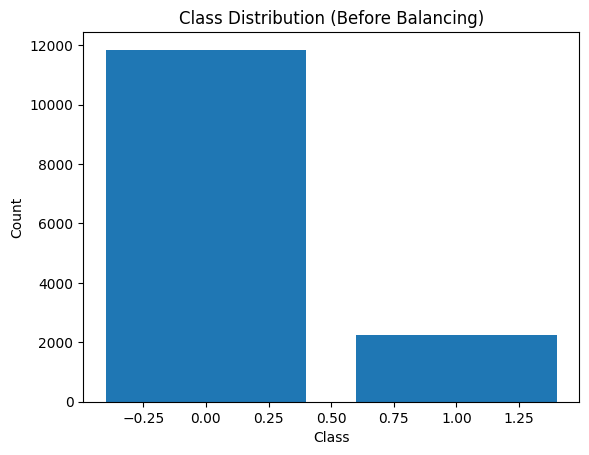

In [72]:
unique, counts = np.unique(target_data, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Before Balancing)")
plt.show()


In [73]:
balanced_input_data =  np.delete(input_data,indices_to_remove,axis = 0)
balanced_target_data = np.delete(target_data,indices_to_remove,axis = 0)

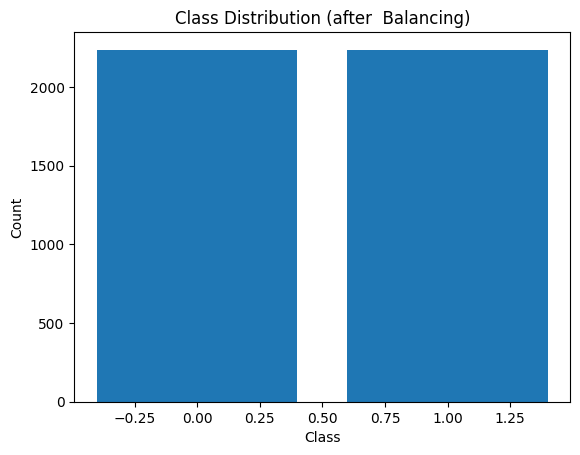

In [74]:
unique, counts = np.unique(balanced_target_data, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (after  Balancing)")
plt.show()

# shuffling the data

In [75]:
indices = np.arange(balanced_target_data.shape[0])
np.random.shuffle(indices)

input_data = balanced_input_data[indices]
target_data = balanced_target_data[indices]

#scaling the data

In [76]:
scaled_input = preprocessing.scale(input_data)

## splitting into train,test and validation

In [77]:
sample_count = int(target_data.shape[0])

train_count = int(0.8*(sample_count))
validation_count = int(0.1*(sample_count))
test_count = sample_count-train_count-validation_count

train_input_data = scaled_input[:train_count]
train_target_data = target_data[:train_count]

validation_input_data = scaled_input[train_count:validation_count+train_count]
validation_target_data = target_data[train_count:validation_count +train_count]

test_input_data = scaled_input[validation_count+train_count:]
test_target_data = target_data[validation_count+train_count:]

In [78]:
hidden_layer_size = 50
output_size = 2

model = tf.keras.Sequential([
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(output_size,activation = 'softmax')
])

batch_size = 100
max_epochs = 100
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])


## compiling the model

In [79]:
batch_size = 100
max_epochs = 100
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

## fitting the model

In [80]:
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)
history = model.fit(train_input_data,train_target_data,
          validation_data = (validation_input_data,validation_target_data),
          batch_size = batch_size,
          verbose = 2,
          epochs = max_epochs,
          callbacks = [early_stopping]
          )

Epoch 1/100
36/36 - 2s - 61ms/step - accuracy: 0.7184 - loss: 0.5754 - val_accuracy: 0.7494 - val_loss: 0.5095
Epoch 2/100
36/36 - 0s - 8ms/step - accuracy: 0.7768 - loss: 0.4567 - val_accuracy: 0.7629 - val_loss: 0.4314
Epoch 3/100
36/36 - 0s - 5ms/step - accuracy: 0.7893 - loss: 0.4062 - val_accuracy: 0.7696 - val_loss: 0.4017
Epoch 4/100
36/36 - 0s - 5ms/step - accuracy: 0.7963 - loss: 0.3820 - val_accuracy: 0.7897 - val_loss: 0.3809
Epoch 5/100
36/36 - 0s - 4ms/step - accuracy: 0.8025 - loss: 0.3666 - val_accuracy: 0.7808 - val_loss: 0.3730
Epoch 6/100
36/36 - 0s - 4ms/step - accuracy: 0.8125 - loss: 0.3565 - val_accuracy: 0.7830 - val_loss: 0.3679
Epoch 7/100
36/36 - 0s - 4ms/step - accuracy: 0.8150 - loss: 0.3498 - val_accuracy: 0.7987 - val_loss: 0.3607
Epoch 8/100
36/36 - 0s - 4ms/step - accuracy: 0.8187 - loss: 0.3457 - val_accuracy: 0.8009 - val_loss: 0.3557
Epoch 9/100
36/36 - 0s - 5ms/step - accuracy: 0.8114 - loss: 0.3450 - val_accuracy: 0.7964 - val_loss: 0.3578
Epoch 10/

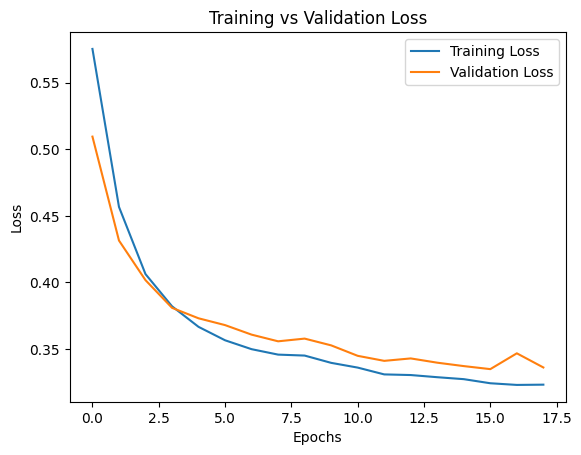

In [81]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


## checking accuracy the model

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


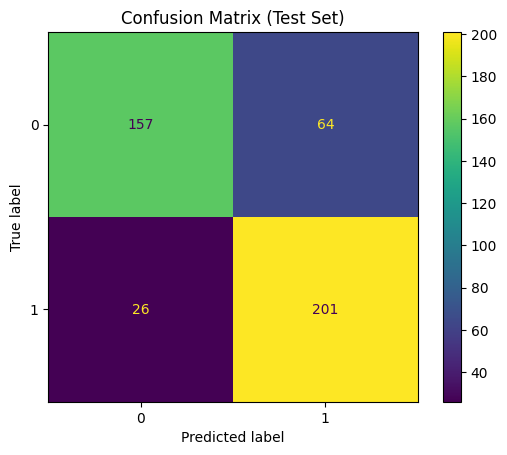

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict probabilities
y_pred_probs = model.predict(test_input_data)

# Convert softmax probabilities to class labels (0 or 1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_target_data, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.show()



In [82]:
test_loss,test_accuracy = model.evaluate(test_input_data,test_target_data)
test_loss,test_accuracy

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8175 - loss: 0.3320 


(0.35426902770996094, 0.7991071343421936)